# Surface flux response to a downwelling-longwave forcing — NSA C1 observations

The observational twin of `ERA5/surface_energy_budget/turbulent_flux_response_to_DLR.ipynb`:
the same question — *if the downwelling longwave at the Arctic surface changes by
1 W m⁻², where does that watt go?* — answered from the ARM instruments at
Utqiaġvik (NSA C1) for the 2025/26 cold season instead of from ERA5. The
framework is Sledd et al. (2025), *JGR Atmospheres*, 130, e2024JD042578, after
Miller et al. (2017): regress each surface term on the radiative forcing and
read the slope as the fraction of the forcing that term disposes of.

## Sign convention

Everything in the observational product is already in the **Sledd** convention:
the turbulent fluxes `sh_up`, `lh_up` are **positive upward** (energy leaving the
surface), $G$ is positive **toward** the surface and its responder is $-G$, and
the radiative net fluxes are positive downward. Nothing here needs the sign
gymnastics of the ERA5 notebook (whose fluxes are stored positive downward); a
positive fraction always means *energy leaving the surface per W m⁻² arriving*.

Under the winter inversion the surface is usually colder than the 2-m air, so
`sh_up` is **negative** most of the time (heat flows down into the snow). A DLR
increase warms the skin, shrinks the skin-to-air deficit, and makes `sh_up`
*less negative*: the downward flux weakens. That is a positive $f_{SH}$ — the
turbulent term damps the forcing — even though the flux itself points down. The
sign of the flux is not the sign of the response.

## The important caveat

Nothing here is a controlled forcing experiment. Every slope is a covariance
across the natural synoptic variability of one season: high-DLR periods are
cloudy, and cloudy periods differ in wind, air mass and stability. Two
estimators are reported throughout — the plain regression (Sledd's) and the
regression holding $T_{2m}$ fixed — and they bracket the causal answer from
opposite sides.

## Contents

| section | figure |
|---|---|
| variables | which Sledd terms are measured, parameterized, or estimated here |
| 1 | every responder against DLR, all sky (Sledd Fig. 1 layout) |
| 2–3 | sensible and latent heat against DLR, by population |
| 4 | LWU, NA and $-G$ against DLR |
| 5 | the partition by population, with bootstrap intervals; the ledger |
| 6 | thermal freedom: $dT_{skin}/d(DLR)$ and $d(T_{skin}-T_{2m})/d(DLR)$ |
| 7 | the control ladder |
| 8 | month by month (Sledd Fig. 2a layout, DLR forcer) with the ERA5 cell |
| 9 | sensitivity to the bulk-flux free parameters |
| 10 | 10-min against hourly |
| 11 | DLR against LWP |
| 12 | the observed partition beside ERA5's at the same cell |

All analysis lives in `arm_nsa/flux_response.py`; this notebook holds none of
its own (autoreload is on).


## What a regression is doing here

The ERA5 notebook of the same name carries a full primer; the short form:

- **A slope is an estimated derivative.** $b = \mathrm{cov}(x, y)/\mathrm{var}(x)$
  is $dy/dx$ averaged over the range of $x$ the data cover. Where the relation
  bends, it is the best single-number summary over that range.
- **The response goes on $y$.** $\mathrm{slope}(y|x)\cdot\mathrm{slope}(x|y) = r^2$,
  so inverting the wrong fit overstates a derivative by $1/r^2$. Every panel
  below fits the responder on the forcer.
- **$r^2$ is a description of the scatter, not a verdict on the slope.** A slope
  can be well determined through a lot of scatter. Sledd et al. scale their
  markers by $r^2$ for exactly this reason, and so do the monthly figures here.
- **Every number is a covariance across the season's weather**, not a controlled
  experiment. High-DLR periods are cloudy, warm, windy periods. The plain slope
  (Sledd's estimator) is the headline; the multiple regression that holds
  $T_{2m}$ fixed is the other end of the confounder-versus-mediator bracket and
  is drawn beside it.
- **Confidence intervals are moving-block bootstrap intervals** (7-day blocks,
  the units the record supplies independently), never the textbook standard
  error, which assumes independent samples and is too small by one to two
  orders of magnitude on these data. One season holds 26 blocks, so the
  intervals are wide — and honest.


## Setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd() if (Path.cwd() / "arm_nsa").is_dir() else Path.cwd().parent
sys.path.insert(0, str(REPO))
from arm_nsa import flux_response as fr

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100          # on-screen; saved PNGs use fr.FIG_DPI

SEASON = "2025-10-01_2026-03-31"
PRODUCTS = REPO / "data" / "processed"
SAVE_DIR = REPO / "figures" / "seb_flux_response"   # None to only display
N_BOOT = 1000                                        # bootstrap draws (2000 in the ERA5 notebooks)


## Load the two products and the ERA5 cell

In [2]:
# The 10-min product is the Sledd et al. (2025) cadence (their observations are
# 10-min means); the hourly product is the ERA5 cadence. Both were built by
# scripts/build_nsa_seb_hourly.py from the same 1-min streams.
OBS = fr.load_product(PRODUCTS / f"nsa_seb_10min_{SEASON}.nc")
OBS_H = fr.load_product(PRODUCTS / f"nsa_seb_hourly_{SEASON}.nc")
MASKS = fr.population_masks(OBS)
MASKS_H = fr.population_masks(OBS_H)

# ERA5 at the grid cell nearest NSA C1 (71.25 N, 156.5 W; a coastal cell, ERA5
# land fraction 0.62), on the same Eq. (1) terms via the ERA5 seb_terms module.
ERA5 = fr.load_era5_cell("2025-10-01", "2026-03-31")
ERA5_MASKS = fr.population_masks(ERA5) if ERA5 is not None else None

print(f"10-min samples: {OBS.sizes['time']:,}   hourly: {OBS_H.sizes['time']:,}   "
      f"ERA5 hours: {ERA5.sizes['time'] if ERA5 is not None else 'n/a'}")
print("populations (10-min):", {k: int(v.sum()) for k, v in MASKS.items()})
print()
print(fr.variable_check_table(OBS))


10-min samples: 26,160   hourly: 4,362   ERA5 hours: 4368
populations (10-min): {'all': 26160, 'cloudy': 17366, 'liquid': 11017, 'clear': 6258}



term             valid   how it is obtained at NSA C1
LWD             100.0%   measured (SKYRAD pyrgeometers, QCRAD QC; two-pyrgeometer best estimate)
LWU             100.0%   measured (GNDRAD pyrgeometer at 10 m)
SWD, SWU         99.8%   measured (QCRAD); SWN = SWD - SWU
T_skin          100.0%   IRT brightness T corrected for emissivity 0.985 + reflected LWD; LWU inversion as fallback (Sledd: LWU inversion)
SH               99.6%   BULK PARAMETERIZATION (MOST; Sledd: eddy covariance)
LH               99.6%   BULK PARAMETERIZATION (Sledd: eddy covariance)
G               100.0%   ESTIMATED from T_skin history (thermal inertia); also as Eq. (5) residual (Sledd: IMB conduction + storage in a 6-cm slab)
SWT               --     zero: snow deeper than the 6-cm slab over opaque tundra (Sledd: Beer's law, Eq. 6)
M                 --     zero, frozen surface Oct-Mar (Sledd: residual, ~0 in winter)
NA               99.4%   LWD - LWU + SWN - SH - LH (Eq. 5)
T_2m, U_10m     100.0%   measured (ME

## Do we have the right variables? Sledd et al. (2025) term by term

Sledd et al. define the budget (their Eq. 1, turbulent fluxes positive **away**
from the surface, $G$ positive toward it)

$$LWD - LWU + SWD - SWU - SWT - SH - LH + G = M$$

and evaluate the response of every term on the right-hand side of

$$\frac{\partial(LWD + SWN)}{\partial(LWD + SWN)} = 1 =
\frac{\partial(LWU + SH + LH + M - SWT - G)}{\partial(LWD + SWN)} \qquad \text{(their Eq. 9)}$$

with a least-squares slope per calendar month on 10-min data. What they had at
MOSAiC, and what NSA C1 supplies for the same term:

| term | MOSAiC (Sledd et al. Sect. 2.1) | NSA C1 in this notebook | status |
|---|---|---|---|
| LWD, LWU | pyrgeometers at 1 m (down) and 3 m (up); ±2.6 / ±1 W m⁻² | QCRAD 1-min pyrgeometers, LWU at 10 m; LWD is the two-pyrgeometer best estimate because pyrgeometer 1 failed for 44 days of Dec–Feb (README) | **measured** |
| SWD, SWU | pyranometers, ±3–4.5 W m⁻² | QCRAD 1-min | **measured** |
| $T_{skin}$ | inverted from LWU, ε = 0.985 | GNDIRT brightness temperature corrected with ε = 0.985 and the reflected LWD; LWU inversion as fallback and as a cross-check (they agree to −0.5 ± 0.4 K outside the calm-clear frost episodes) | **measured** (two routes) |
| SH, LH | eddy covariance (20-Hz sonic + gas analyser); SH ±4.8 W m⁻², LH ±50% | **no eddy-covariance system exists at Barrow** — bulk-aerodynamic parameterization (MOST, Grachev et al. 2007 stable functions, Andreas 1987 scalar roughness, $z_0$ = 3×10⁻⁴ m) from measured $T_{skin}$, $T_{2m}$, RH, $U_{10}$, $p$ | **parameterized** |
| G | conduction + storage in a 6-cm slab from ice-mass-balance buoys | **no soil/snow instrumentation at Barrow** — thermal-inertia estimate from the $T_{skin}$ history (Wang & Bras 1999), and the Eq. (5) residual | **estimated** |
| SWT | Beer's law through a 6-cm snow/ice slab (their Eq. 6) | zero: the snowpack is deeper than 6 cm all season and the tundra below is opaque, so penetrating shortwave is absorbed in the pack and is part of $G$ | assumed 0 |
| M | residual | zero (frozen surface, Oct–Mar) | 0 |
| $T_{2m}$, $U$ | tower | MET 1-min (2-m T/RH, 10-m wind) | **measured** |
| cadence | 10 min | 10 min (this product) and 1 h (for ERA5) | matched |

**So the radiative half of the framework — the forcer and the largest responder
(LWU), which carries half of every anomaly — is on the same observational
footing as MOSAiC. The turbulent and subsurface responders are not.** At
MOSAiC they were independent measurements and their sum closing to one
(Sledd's "total measured response", 0.94–1.08 in winter) was a *finding*. Here
SH and LH are functions of the measured skin-to-air temperature difference and
wind, and $G$ is a function of the measured skin temperature history: all
three responders are downstream of $T_{skin}$, so their sum closing to one is a
weaker statement — it says the parameterizations are mutually consistent with
the measured radiation, not that they are right. What *is* independently
testable is the comparison of the two routes to the subsurface response,
$dNA/dF$ (measured radiation minus parameterized turbulence) and $d(-G_{TI})/dF$
(thermal inertia), which is the analogue of Sledd's NA-versus-$-G$ comparison.


## Verify the algebra, then the numbers

`self_check` asserts that a variable regressed on itself gives exactly 1, that the
remainder of the partition equals the direct regression of NA (linearity), that
holding a variable fixed drives its own slope to zero, and that the two fit
directions multiply to $r^2$. `print_report` is the partition for every
population under both estimators — the numbers the figures draw.


In [3]:
fr.self_check(OBS)
fr.print_report(OBS, MASKS, forcer="lwd")


Forcer: DLR    (fractions = energy leaving the surface per W m-2 of forcing)
  all     none      f_lwu=+0.694  f_sh=+0.091  f_lh=+0.037  f_sw=-0.020  f_res=+0.198  f_g_ti=+0.109  total_measured=+0.931  | dTs/dF=0.1937 K/(W m-2)  d(Ts-T2m)/dF=+0.0190  n=26160
  all     t2m       f_lwu=+0.147  f_sh=+0.383  f_lh=+0.072  f_sw=+0.001  f_res=+0.396  f_g_ti=+0.294  total_measured=+0.897  | dTs/dF=0.0505 K/(W m-2)  d(Ts-T2m)/dF=+0.0505  n=26160
  cloudy  none      f_lwu=+0.795  f_sh=+0.055  f_lh=+0.052  f_sw=-0.013  f_res=+0.112  f_g_ti=+0.076  total_measured=+0.978  | dTs/dF=0.2095 K/(W m-2)  d(Ts-T2m)/dF=+0.0095  n=17366
  cloudy  t2m       f_lwu=+0.133  f_sh=+0.353  f_lh=+0.075  f_sw=+0.033  f_res=+0.406  f_g_ti=+0.333  total_measured=+0.894  | dTs/dF=0.0447 K/(W m-2)  d(Ts-T2m)/dF=+0.0447  n=17366
  liquid  none      f_lwu=+0.907  f_sh=+0.009  f_lh=+0.061  f_sw=-0.024  f_res=+0.047  f_g_ti=+0.043  total_measured=+1.020  | dTs/dF=0.2330 K/(W m-2)  d(Ts-T2m)/dF=+0.0056  n=11017
  liquid  t2m

### 1. Every responder against DLR — all sky

The Sledd et al. (2025) Fig. 1 layout on the Barrow record: six density-coloured
scatters of the 10-min data, the unweighted least-squares line in black, its
slope and $r^2$ in the box. The slope of each panel *is* that term's response.
LWU is the term that behaves (a near-straight line, high $r^2$); SH and LH are
the bulk parameterization's responses; NA is the atmospheric-side remainder and
$-G_{TI}$ the thermal-inertia estimate of the same subsurface flux; SW$_{net}$ is
the shortwave co-variation that the DLR-only forcer leaves on the responder side.


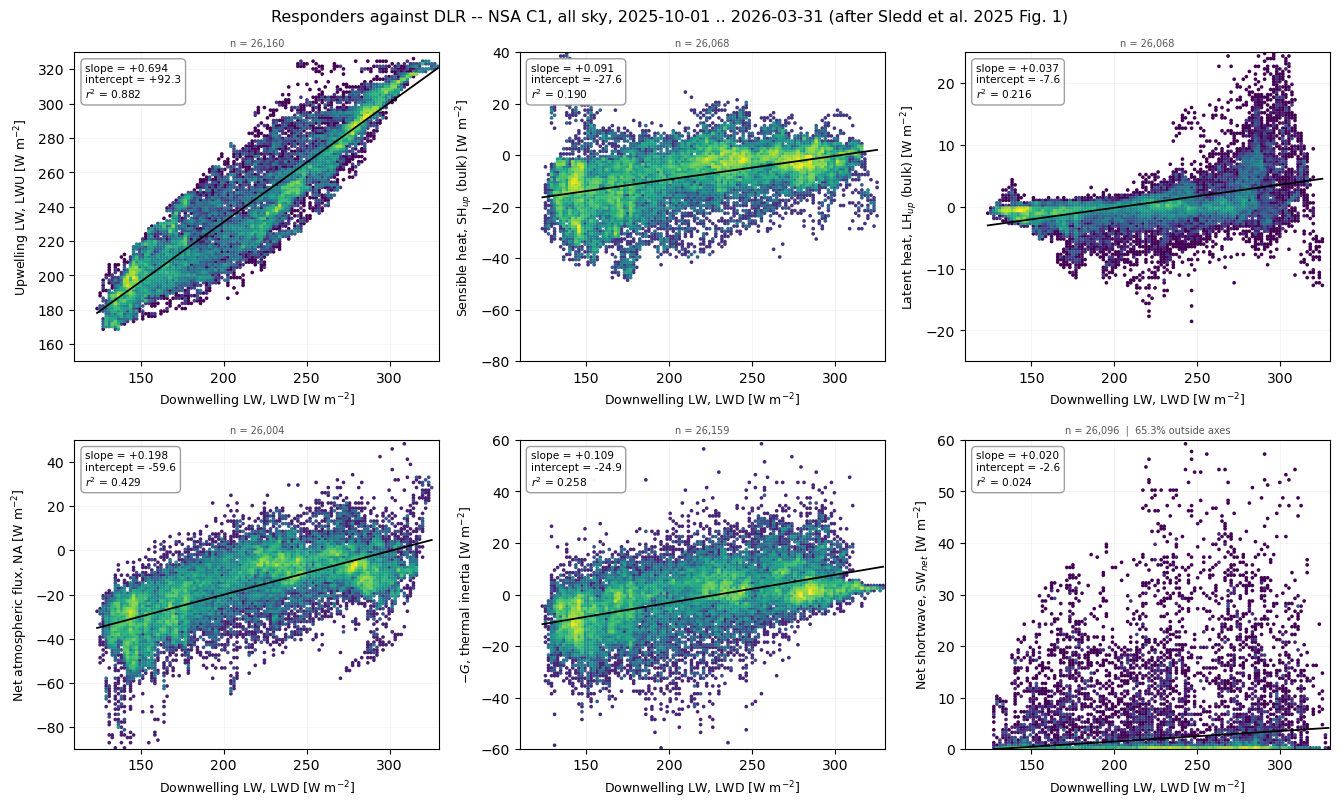

In [4]:
fr.fig_all_responders(OBS, MASKS["all"], forcer="lwd", population="all", out_dir=SAVE_DIR);

### 2. Sensible heat flux against DLR, by population

Populations: all sky; cloudy (ARSCL cloud fraction ≥ 0.95 within the averaging
window); clear (≤ 0.05). The liquid-bearing overcast population (cloudy and
MWR LWP ≥ 10 g m⁻²) is in the report above. Expect the clear-sky slope to be
the smallest: under clear skies DLR varies with water vapour and temperature
advection rather than cloud, and the skin follows the air.


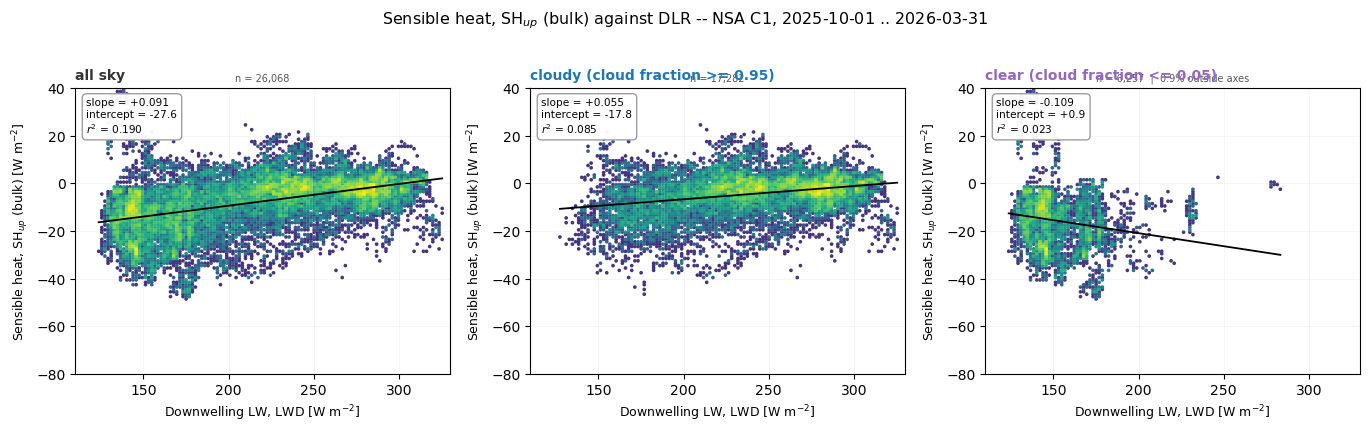

In [5]:
fr.fig_responder_vs_forcer(OBS, MASKS, "sh_up", forcer="lwd", out_dir=SAVE_DIR);

### 3. Latent heat flux against DLR

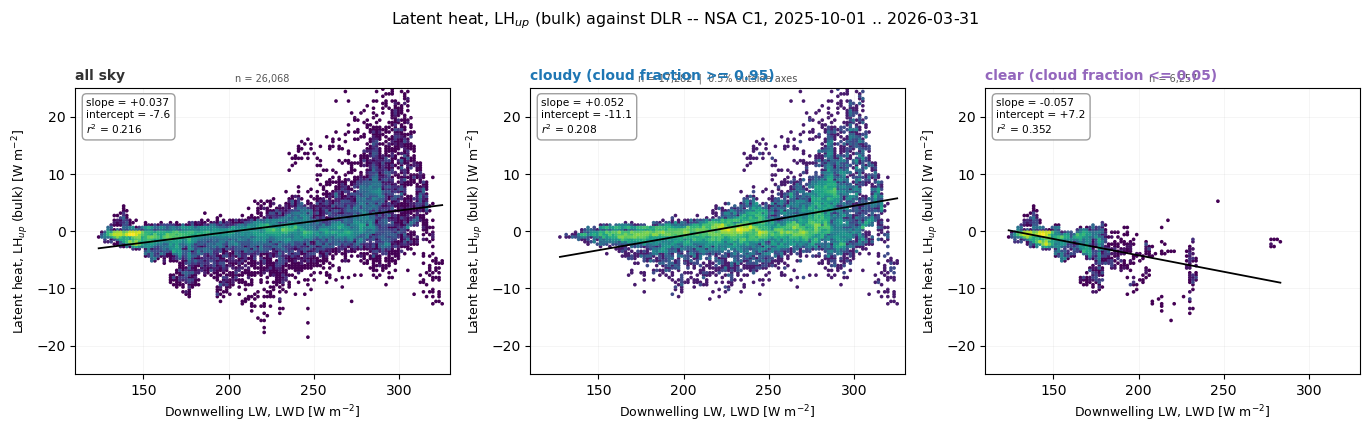

In [6]:
fr.fig_responder_vs_forcer(OBS, MASKS, "lh_up", forcer="lwd", out_dir=SAVE_DIR);

### 4. Upwelling longwave, the net atmospheric flux, and $-G$ against DLR

LWU is the measured term and carries the largest share. NA = LWD − LWU + SWN −
SH − LH is what the atmosphere leaves for the subsurface (Sledd Eq. 5) and its
slope equals $1 - f_{LWU} - f_{SH} - f_{LH} - f_{SW}$ exactly. $-G_{TI}$ is the
independent-in-method (not independent-of-$T_{skin}$) estimate of the same
quantity; the difference between the last two panels' slopes is the closure
error of the observational budget.


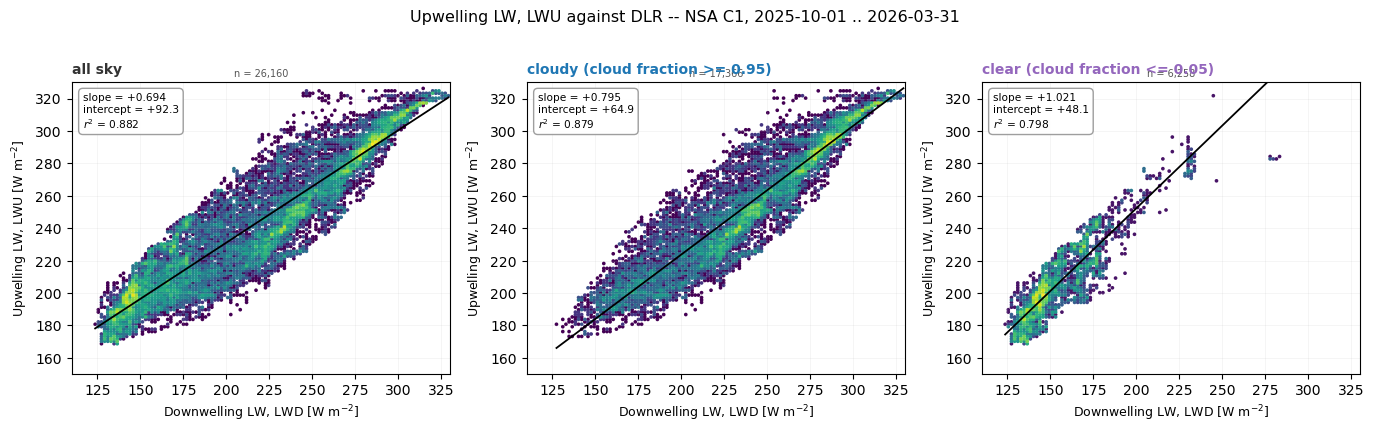

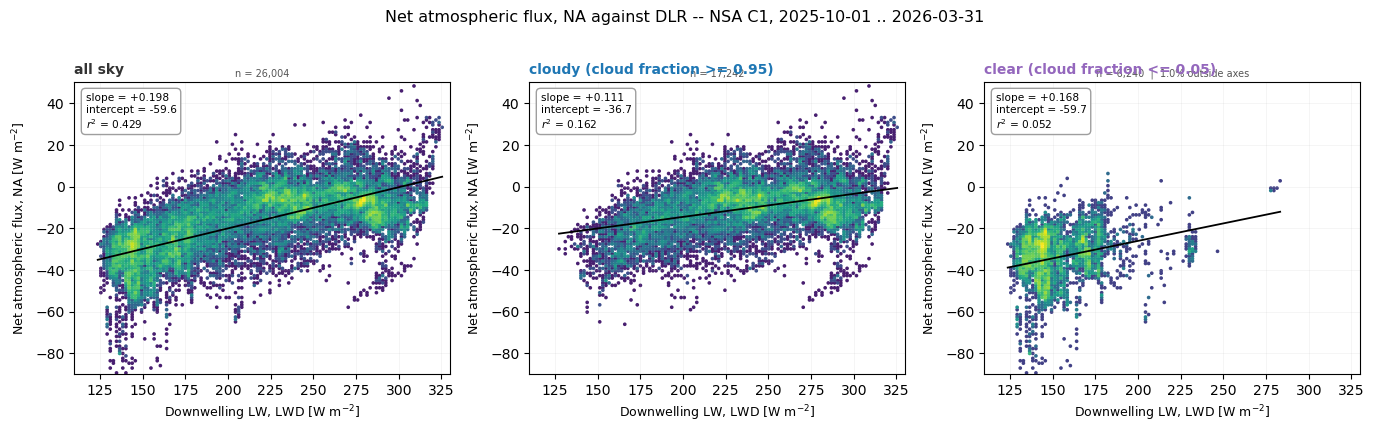

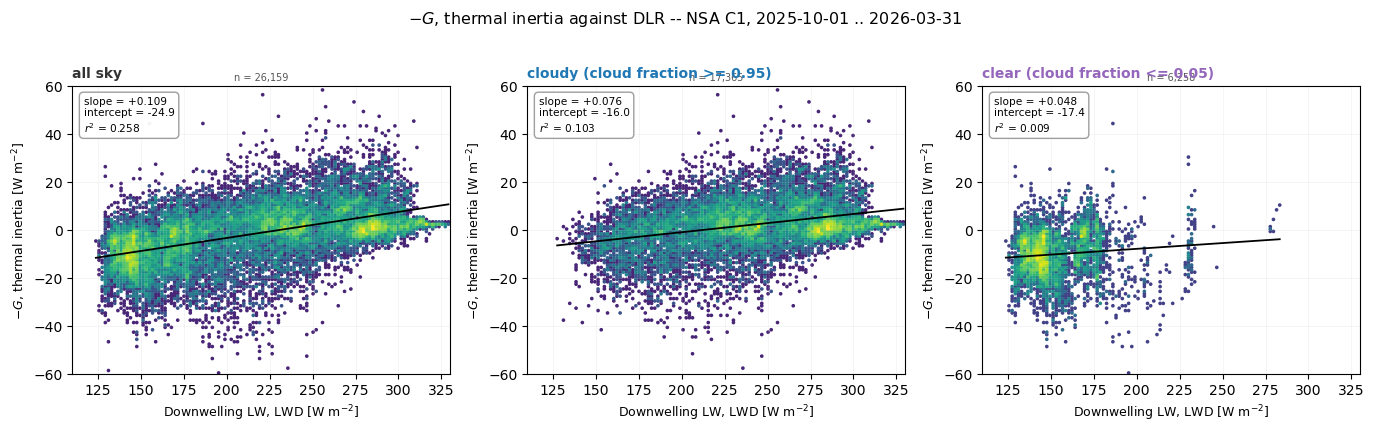

In [7]:
fr.fig_responder_vs_forcer(OBS, MASKS, "lwu", forcer="lwd", out_dir=SAVE_DIR);
fr.fig_responder_vs_forcer(OBS, MASKS, "na", forcer="lwd", out_dir=SAVE_DIR);
fr.fig_responder_vs_forcer(OBS, MASKS, "neg_g_ti", forcer="lwd", out_dir=SAVE_DIR);


## 5. The partition, and how it is estimated

With every responder counted as energy leaving the surface, differentiating the
budget with respect to DLR gives

$$1 = f_{LWU} + f_{SH} + f_{LH} + f_{SW} + f_{res}, \qquad
f_{SW} = -\frac{d(SW_{net})}{d(DLR)}, \quad f_{res} = \frac{d(NA)}{d(DLR)}$$

which sums to one by construction ($f_{res}$ is the remainder). $f_G^{TI} =
d(-G_{TI})/d(DLR)$ is drawn beside it as the independent estimate of the same
subsurface response. Error bars are 95% moving-block bootstrap intervals; the
table prints the bootstrap standard error next to the textbook one so the size
of the independence assumption is a number rather than an assertion.


populationterm         value              95% CI  boot SE  naive SE  ratio
all       f_lwu        0.694   [+0.635, +0.730]    0.024    0.0016   15.0
all       f_sh         0.091   [+0.061, +0.127]    0.017    0.0012   14.4
all       f_lh         0.037   [+0.021, +0.052]    0.008    0.0004   17.9
all       f_sw        -0.020   [-0.035, -0.006]    0.007       nan    nan
all       f_res        0.198   [+0.158, +0.255]    0.025    0.0014   17.5
all       f_g_ti       0.109   [+0.085, +0.145]    0.015    0.0011   13.4
cloudy    f_lwu        0.795   [+0.737, +0.829]    0.023    0.0022   10.3
cloudy    f_sh         0.055   [+0.034, +0.083]    0.012    0.0014    9.0
cloudy    f_lh         0.052   [+0.027, +0.070]    0.011    0.0008   13.9
cloudy    f_sw        -0.013   [-0.032, +0.009]    0.010       nan    nan
cloudy    f_res        0.112   [+0.075, +0.169]    0.024    0.0019   12.3
cloudy    f_g_ti       0.076   [+0.048, +0.122]    0.019    0.0017   11.1
liquid    f_lwu        0.907   [+0.86

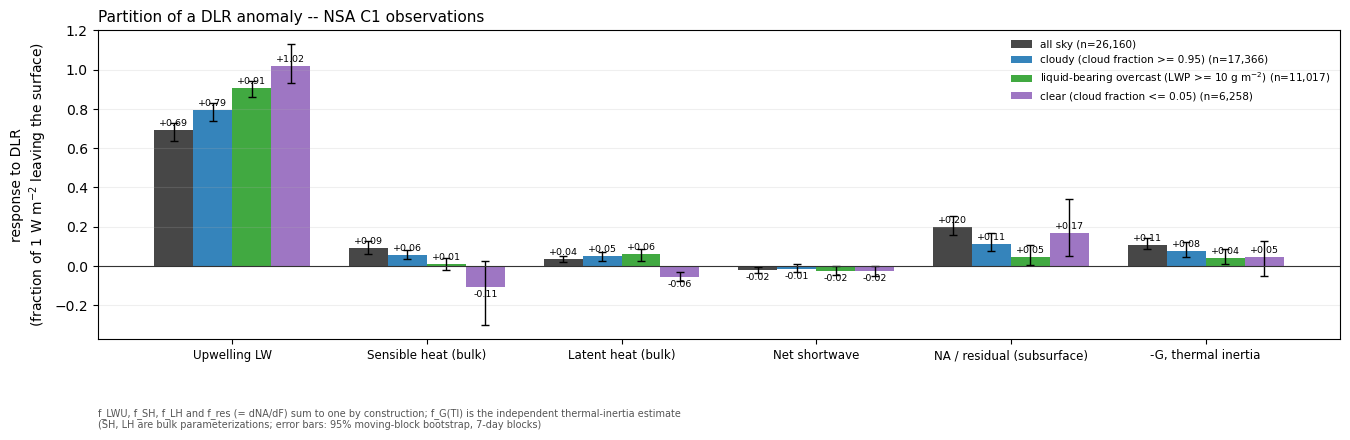

In [8]:
POPS = ("all", "cloudy", "liquid", "clear")
PARTS_LWD = {p: fr.partition(OBS, MASKS[p], "lwd") for p in POPS}
CI_LWD = {p: fr.bootstrap_partition(OBS, MASKS[p], "lwd", n_boot=N_BOOT) for p in POPS}
fr.fig_partition_bars(PARTS_LWD, "lwd", intervals=CI_LWD, out_dir=SAVE_DIR);

print(f"{'population':<10}{'term':<10}{'value':>8}{'95% CI':>20}{'boot SE':>9}{'naive SE':>10}{'ratio':>7}")
naive_key = {"f_lwu": "lwu", "f_sh": "sh_up", "f_lh": "lh_up", "f_res": "na", "f_g_ti": "neg_g_ti"}
for p in POPS:
    for t in ("f_lwu", "f_sh", "f_lh", "f_sw", "f_res", "f_g_ti"):
        r = CI_LWD[p][t]
        nse = fr.naive_se(OBS, MASKS[p], naive_key[t], "lwd") if t in naive_key else float("nan")
        print(f"{p:<10}{t:<10}{r['value']:>8.3f}   [{r['lo']:+.3f}, {r['hi']:+.3f}]{r['se']:>9.3f}{nse:>10.4f}{r['se']/nse if nse == nse else float('nan'):>7.1f}")


### The ledger

The fractions can be negative — a term that *arrives with* the DLR anomaly is a
source, not a sink — and a stacked bar hides that. The ledger of the ERA5
notebook normalises both sides by the gross energy in motion so supply and
disposal each sum to one for every population.


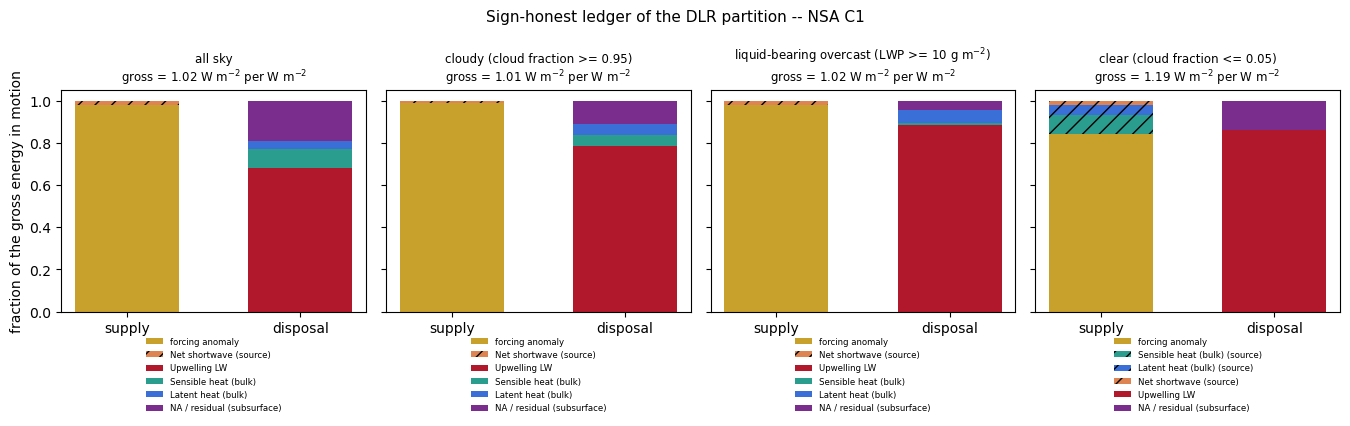

In [9]:
fr.fig_ledger(PARTS_LWD, "lwd", out_dir=SAVE_DIR);

## 6. Thermal freedom

$dT_{skin}/d(DLR)$ is how far the surface is free to warm per W m⁻²; it sets
$f_{LWU}$ through Stefan–Boltzmann ($4\varepsilon\sigma T^3 \approx 3.6$ W m⁻² K⁻¹ at 250 K,
so 0.19 K per W m⁻² ≈ 0.68 of the anomaly re-emitted). The sign of the
turbulent response is decided by $d(T_{skin} - T_{2m})/d(DLR)$: positive means
the surface warms faster than the air and the upward flux strengthens (or the
downward one weakens).


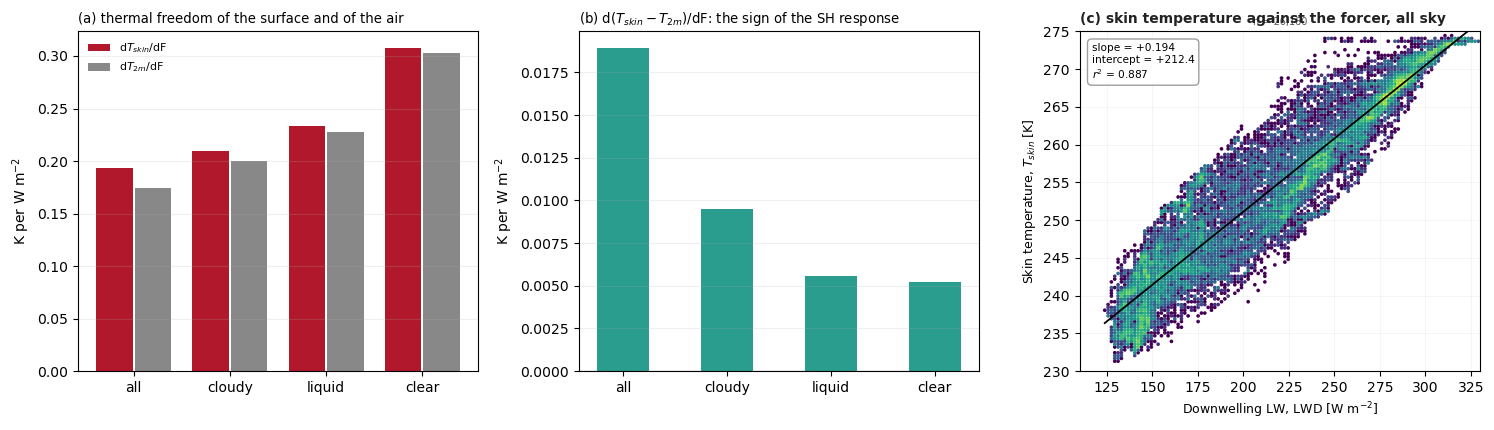

In [10]:
fr.fig_thermal_freedom(OBS, MASKS, forcer="lwd", out_dir=SAVE_DIR);

## 7. The control ladder

Plain regression (Sledd), then holding $T_{2m}$ fixed, then $T_{2m}$ and wind.
Holding $T_{2m}$ fixed removes the air-mass confound *and* the genuine chain
DLR → $T_{skin}$ → $T_{2m}$; over a snow surface whose air is largely slaved to it
that deletes most of $f_{LWU}$, which is why the controlled estimate is a lower
bound on the radiative response and not a corrected one.


Forcer: DLR    (fractions = energy leaving the surface per W m-2 of forcing)
  all     none      f_lwu=+0.694  f_sh=+0.091  f_lh=+0.037  f_sw=-0.020  f_res=+0.198  f_g_ti=+0.109  total_measured=+0.931  | dTs/dF=0.1937 K/(W m-2)  d(Ts-T2m)/dF=+0.0190  n=26160
  all     t2m       f_lwu=+0.147  f_sh=+0.383  f_lh=+0.072  f_sw=+0.001  f_res=+0.396  f_g_ti=+0.294  total_measured=+0.897  | dTs/dF=0.0505 K/(W m-2)  d(Ts-T2m)/dF=+0.0505  n=26160
  all     t2m_wind  f_lwu=+0.148  f_sh=+0.375  f_lh=+0.075  f_sw=+0.003  f_res=+0.398  f_g_ti=+0.300  total_measured=+0.899  | dTs/dF=0.0527 K/(W m-2)  d(Ts-T2m)/dF=+0.0527  n=26160
  cloudy  none      f_lwu=+0.795  f_sh=+0.055  f_lh=+0.052  f_sw=-0.013  f_res=+0.112  f_g_ti=+0.076  total_measured=+0.978  | dTs/dF=0.2095 K/(W m-2)  d(Ts-T2m)/dF=+0.0095  n=17366
  cloudy  t2m       f_lwu=+0.133  f_sh=+0.353  f_lh=+0.075  f_sw=+0.033  f_res=+0.406  f_g_ti=+0.333  total_measured=+0.894  | dTs/dF=0.0447 K/(W m-2)  d(Ts-T2m)/dF=+0.0447  n=17366
  cloudy  t2m

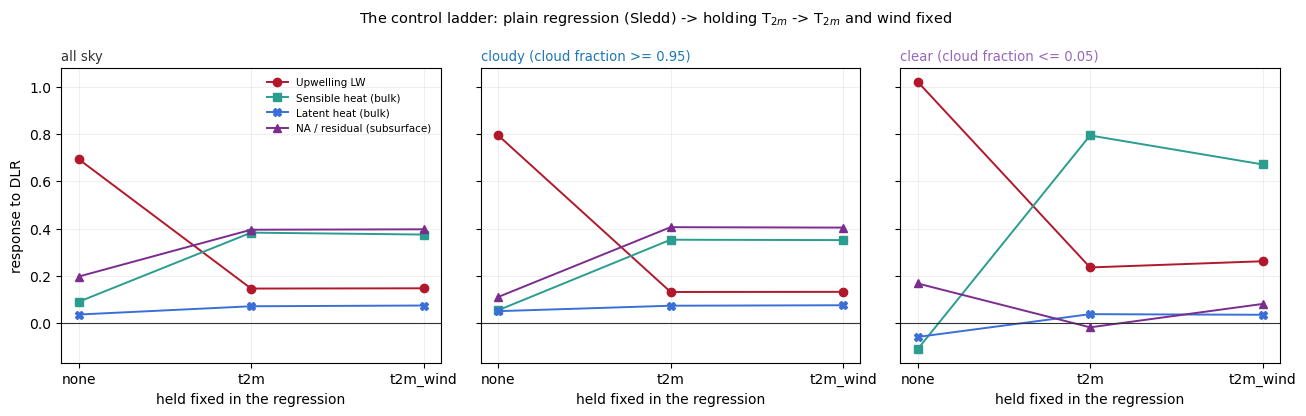

In [11]:
fr.fig_control_ladder(OBS, MASKS, forcer="lwd", out_dir=SAVE_DIR);
fr.print_report(OBS, MASKS, forcer="lwd", controls=("none", "t2m", "t2m_wind"))


## 8. Month by month, against the ERA5 cell

The Sledd et al. Fig. 2a layout with the DLR forcer (their figure uses
DLR + SW$_{net}$; that version is the companion notebook). Marker size scales
with the $r^2$ of each term's monthly regression. Dashed lines are ERA5 at the
grid cell nearest the site, from the same Eq. (1) terms (ERA5 has no $G$).


month   f_LWU    f_SH    f_LH    f_SW   f_res  f_G(TI)   sum+G      n  Tskin C
  Oct   0.558   0.107   0.134  -0.002   0.204    0.210   1.008   4464     -5.5
  Nov   0.506   0.228   0.089  -0.006   0.183    0.116   0.939   4320    -11.9
  Dec   0.564   0.041   0.010  -0.003   0.388    0.213   0.827   4464    -21.8
  Jan   0.619   0.117   0.010  -0.002   0.256    0.157   0.903   4419    -27.7
  Feb   0.561   0.140   0.003  -0.024   0.320    0.202   0.905   4029    -27.6
  Mar   0.595   0.153   0.013  -0.050   0.289    0.160   0.921   4464    -22.7


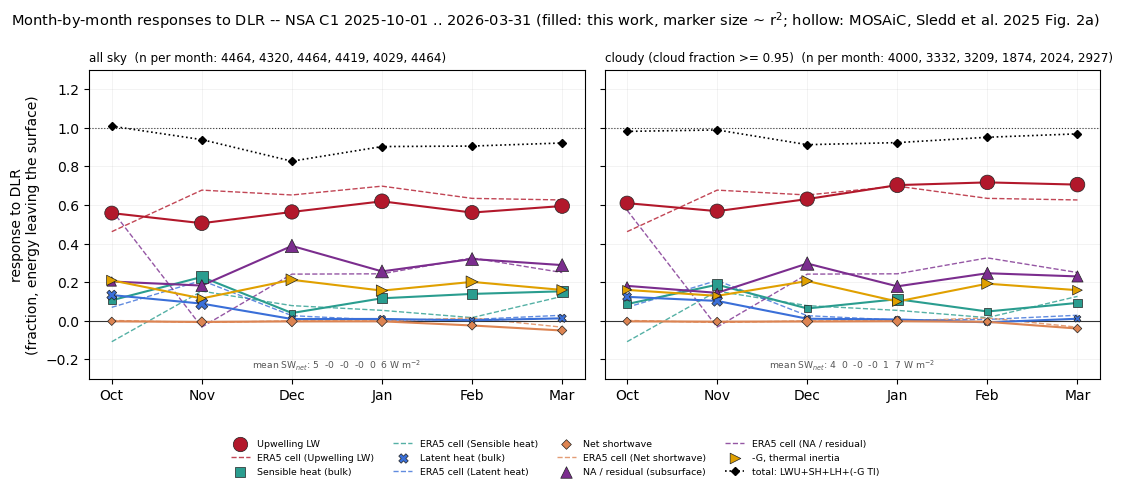

In [12]:
fr.fig_monthly_response(OBS, MASKS, forcer="lwd", populations=("all", "cloudy"), era5=ERA5, show_sledd=False, out_dir=SAVE_DIR);
r = fr.monthly_partition(OBS, MASKS["all"], "lwd")
print(f"{'month':>5}{'f_LWU':>8}{'f_SH':>8}{'f_LH':>8}{'f_SW':>8}{'f_res':>8}{'f_G(TI)':>9}{'sum+G':>8}{'n':>7}{'Tskin C':>9}")
for i, m in enumerate(r["months"]):
    print(f"{fr.WINTER_LABELS[i]:>5}{r['f_lwu'][i]:>8.3f}{r['f_sh'][i]:>8.3f}{r['f_lh'][i]:>8.3f}{r['f_sw'][i]:>8.3f}"
          f"{r['f_res'][i]:>8.3f}{r['f_g_ti'][i]:>9.3f}{r['total_measured'][i]:>8.3f}{int(r['n'][i]):>7}{r['t_skin_mean'][i]-273.15:>9.1f}")


## 9. Sensitivity of the bulk-flux responses to their free parameters

The roughness length is not measured. The bulk fluxes are recomputed from the
product-resolution state for $z_0$ = 10⁻⁴, 3×10⁻⁴ (default) and 10⁻³ m and for
both stable-stability schemes, and the partition is re-fitted each time. What
$z_0$ cannot change is $f_{LWU}$; what it moves between is $f_{SH}$ and $f_{res}$.


scheme          z0 [m]   f_LWU    f_SH    f_LH   f_res  mean SH
grachev2007      1e-04   0.694   0.082   0.034   0.211    -7.33
grachev2007      3e-04   0.694   0.091   0.037   0.198    -8.19
grachev2007      1e-03   0.694   0.101   0.040   0.186    -8.98
beljaars1991     1e-04   0.694   0.080   0.034   0.212    -7.25
beljaars1991     3e-04   0.694   0.090   0.037   0.199    -8.12
beljaars1991     1e-03   0.694   0.100   0.040   0.187    -8.91


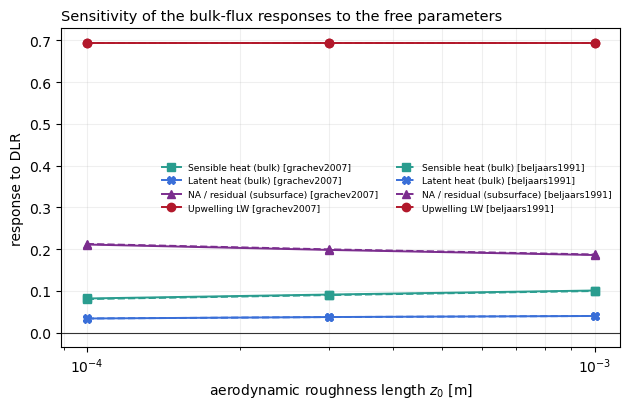

In [13]:
Z0_ROWS = fr.z0_sensitivity(OBS, MASKS["all"], forcer="lwd")
fr.fig_z0_sensitivity(Z0_ROWS, forcer="lwd", out_dir=SAVE_DIR);
print(f"{'scheme':<14}{'z0 [m]':>8}{'f_LWU':>8}{'f_SH':>8}{'f_LH':>8}{'f_res':>8}{'mean SH':>9}")
for r in Z0_ROWS:
    print(f"{r['scheme']:<14}{r['z0_m']:>8.0e}{r['f_lwu']:>8.3f}{r['f_sh']:>8.3f}{r['f_lh']:>8.3f}{r['f_res']:>8.3f}{r['sh_up_mean']:>9.2f}")


## 10. 10-min against hourly

Sledd et al. note that averaging their 10-min data to 6 h raises the LWU
response by ≤ 0.05 and lowers the SH response by a similar amount. The same
comparison here, between the two products built from the same 1-min streams.


10-min, all sky    f_lwu=+0.694  f_sh=+0.091  f_lh=+0.037  f_sw=-0.020  f_res=+0.198  f_g_ti=+0.109  total_measured=+0.931  | dTs/dF=0.1937 K/(W m-2)  d(Ts-T2m)/dF=+0.0190  n=26160
hourly, all sky    f_lwu=+0.700  f_sh=+0.090  f_lh=+0.037  f_sw=-0.020  f_res=+0.194  f_g_ti=+0.105  total_measured=+0.931  | dTs/dF=0.1952 K/(W m-2)  d(Ts-T2m)/dF=+0.0188  n=4362


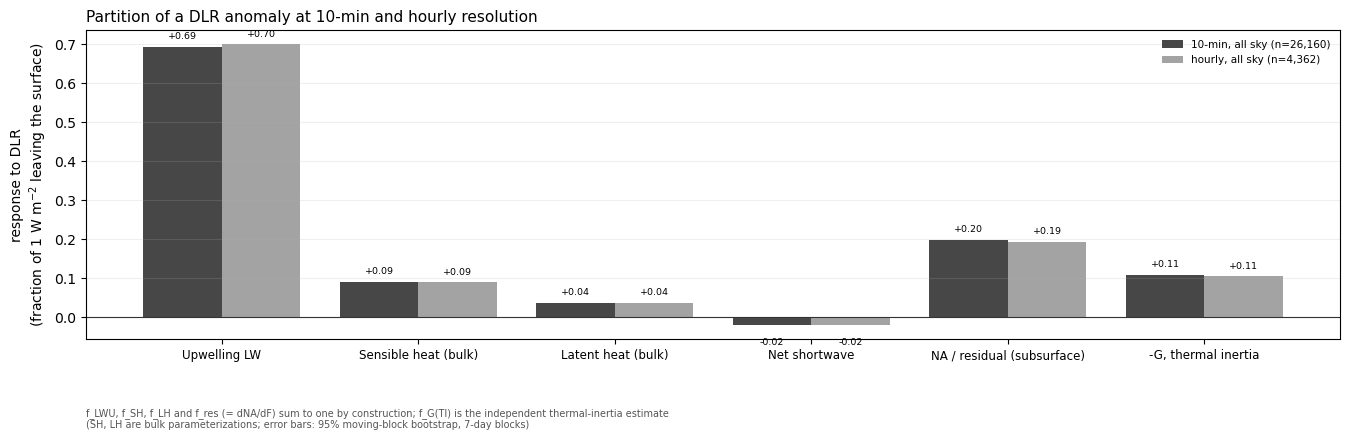

In [14]:
RES = {"10-min, all sky": fr.partition(OBS, MASKS["all"], "lwd"), "hourly, all sky": fr.partition(OBS_H, MASKS_H["all"], "lwd")}
fr.POP_LABELS.update({k: k for k in RES}); fr.POP_COLORS.update({"10-min, all sky": "#333333", "hourly, all sky": "#999999"})
fr.fig_resolution_comparison(RES, "lwd", out_dir=SAVE_DIR);
for k, v in RES.items():
    print(f"{k:<18}", fr.format_partition(v))


## 11. DLR against LWP

The observational relation the ERA5 notebook compares to (its figure 7), on the
same axes, for cloudy 10-min samples. The dashed line is the published Barrow
fit quoted there, $y = 0.27x + 228.26$; the black line is this season's fit.
LWP is the MWRRET retrieval where available and the 3-channel MWR otherwise.


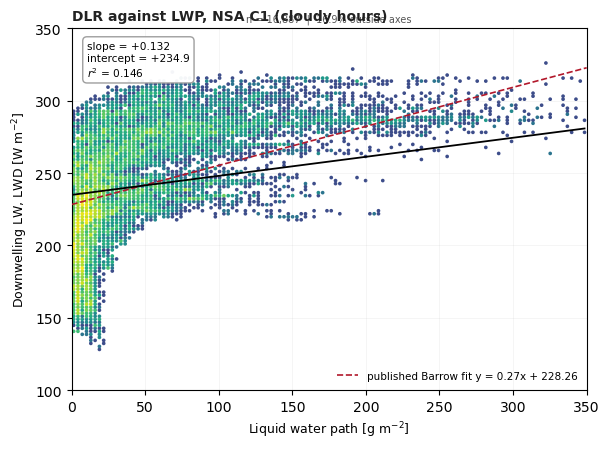

In [15]:
fr.fig_lwp_vs_dlr(OBS, MASKS["cloudy"], out_dir=SAVE_DIR);

## 12. The observed partition beside ERA5's at the same cell

Same season, same forcer, same populations (ERA5 cloud fraction and LWP gates
applied to ERA5's own `tcc` and `tclw`). ERA5's turbulent fluxes are its own
(negated to the Sledd sense); it has no $G$, so only the residual is comparable.
The ERA5 cell is 62% land on a 0.25° grid and mixes tundra with the coastal
sea, which is one reason to expect differences that are not model error.


In [16]:
if ERA5 is not None:
    print(f"{'':<8}{'source':<8}{'f_LWU':>8}{'f_SH':>8}{'f_LH':>8}{'f_SW':>8}{'f_res':>8}{'dTs/dF':>9}{'n':>8}")
    for p in ("all", "cloudy", "clear"):
        for name, d, m in (("obs", OBS_H, MASKS_H[p]), ("ERA5", ERA5, ERA5_MASKS[p])):
            q = fr.partition(d, m, "lwd")
            print(f"{p:<8}{name:<8}{q['f_lwu']:>8.3f}{q['f_sh']:>8.3f}{q['f_lh']:>8.3f}{q['f_sw']:>8.3f}{q['f_res']:>8.3f}{q['dskt_dF']:>9.4f}{q['n']:>8}")
else:
    print("ERA5 files not found; skipping")


        source     f_LWU    f_SH    f_LH    f_SW   f_res   dTs/dF       n
all     obs        0.700   0.090   0.037  -0.020   0.194   0.1952    4362
all     ERA5       0.791   0.084   0.072  -0.021   0.075   0.2083    4368
cloudy  obs        0.830   0.039   0.055  -0.013   0.089   0.2163    2673
cloudy  ERA5       0.804   0.073   0.080  -0.009   0.052   0.2086    2880
clear   obs        1.022  -0.118  -0.054  -0.022   0.171   0.3136     868
clear   ERA5       1.075   0.075  -0.037   0.009  -0.122   0.2744      34


## What this record shows

NSA C1, 1 Oct 2025 – 31 Mar 2026, 26,160 ten-minute samples, plain regression on
DLR unless noted; intervals are 95% moving-block bootstrap (26 blocks of 7 days,
1,000 replicates). Fractions are energy leaving the surface per W m⁻² of DLR.

**The partition, all sky.** $f_{LWU}$ = 0.69 [0.64, 0.73], $f_{SH}$ = 0.09
[0.06, 0.13], $f_{LH}$ = 0.04 [0.02, 0.05], $f_{SW}$ = −0.02, $f_{res}$ = 0.20
[0.16, 0.26]; the thermal-inertia route gives $f_G^{TI}$ = 0.11 [0.09, 0.15].
The surface warms 0.19 K per W m⁻² of DLR.

**By population.** Under liquid-bearing overcast the surface re-radiates 0.91 of
an extra watt and the bulk turbulent response is nil ($f_{SH}$ = 0.01 [−0.02,
0.04]): the skin and the air move together under the cloud
($d(T_{skin} - T_{2m})/d(DLR)$ = 0.006 K per W m⁻²). Under clear skies $f_{LWU}$
exceeds one (1.02 [0.93, 1.13]) and $f_{SH}$ is *negative* (−0.11 [−0.30,
+0.02]): clear-sky DLR variability is water vapour and advection, the air warms
faster than the surface, and the turbulent term delivers energy alongside the
radiative anomaly rather than removing it — the ERA5 notebook's "turbulence adds
to the warming" case, seen in the observations. The clear-sky interval is wide
because that population holds few independent weather situations.

**Two estimators.** Holding $T_{2m}$ fixed moves $f_{LWU}$ from 0.69 to 0.15 and
$f_{SH}$ from 0.09 to 0.38. That is the mediator effect: over snow the 2-m air
is largely slaved to the skin beneath it, so removing its co-variation removes
most of the genuine radiative response. Neither is the causal answer; the plain
slope is the headline (as in Sledd et al.) and the controlled one the lower
bound on the radiative pathway.

**What the free parameters do.** A factor of ten in $z_0$ (10⁻⁴ to 10⁻³ m) moves
$f_{SH}$ from 0.08 to 0.10 and $f_{res}$ the other way; the two stable-stability
schemes differ by 0.001. The bulk SH *response* is robust to the
parameterization's knobs — but it is still the response of a parameterization
(see the variables section and the companion notebook, where it is about half
the eddy-covariance response measured at MOSAiC).

**Cadence and the naive interval.** The 10-min and hourly products agree to
0.006 in every fraction. The textbook standard error is 7–18× smaller than the
bootstrap one; against it every fraction would look determined to three figures.

**ERA5 at the same cell (hourly, all sky).** $f_{LWU}$ 0.79 vs 0.70 observed,
$f_{SH}$ 0.08 vs 0.09, $f_{LH}$ 0.07 vs 0.04, $f_{res}$ 0.08 vs 0.19: ERA5
returns more of the anomaly as emission and leaves less than half as much for
the subsurface. Its cell is 62% land and includes coastal sea, so part of that
is not model error.
